# <span style="color:lightblue">  Numerical exercises 7</span>

In [2]:
import numpy as np
import matplotlib.pyplot as plt

## Exercise 7.2

In [38]:
U = np.loadtxt("../OUTPUT/MC/potential_energy.dat", usecols=1)
U_2 = np.loadtxt("../OUTPUT/MD/potential_energy.dat", usecols=1)

In [3]:
N=500000
s= 2000

x=np.arange(N)
chi=np.zeros(N)

sum= U.sum()
sum2 = np.dot(U,U)

sigma = 1/(sum2/N - (sum/N)**2)

for i in range(s):
    delta = (N- i)

    primo = np.dot(U[:delta],U[i:])
    secondo = np.sum(U[:delta])*np.sum(U[i:])

    chi[i] = (primo-secondo/delta)*sigma/delta
    

In [4]:
chi_2=np.zeros(N)

sum= U_2.sum()
sum2 = np.dot(U_2,U_2)

sigma = 1/(sum2/N - (sum/N)**2)

for i in range(s):
    delta = (N- i)

    primo = np.dot(U_2[:delta],U_2[i:])
    secondo = np.sum(U_2[:delta])*np.sum(U_2[i:])

    chi_2[i] = (primo-secondo/delta)*sigma/delta

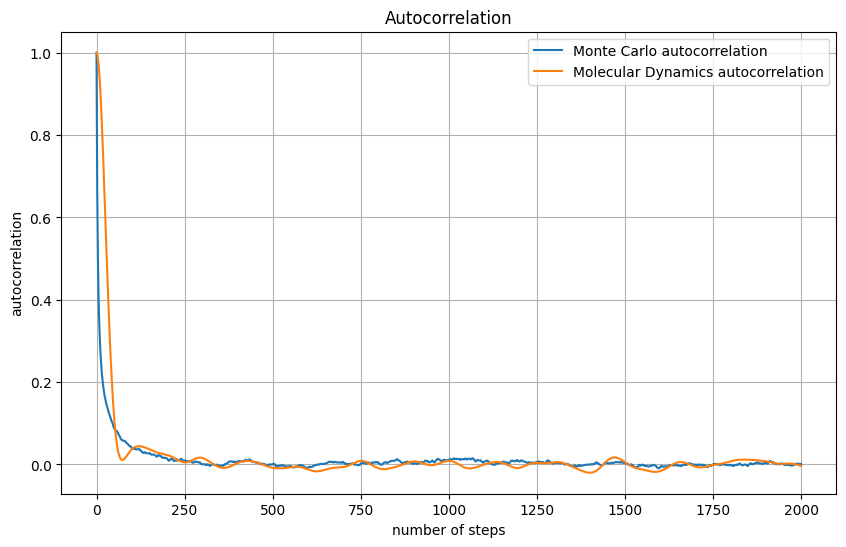

In [33]:
plt.figure(figsize=(10, 6)) 
plt.plot(x[:s], chi[:s], label= "Monte Carlo autocorrelation")
plt.plot(x[:s], chi_2[:s], label = "Molecular Dynamics autocorrelation");

plt.xlabel("number of steps")
plt.ylabel("autocorrelation")

plt.title("Autocorrelation") 
plt.grid(True)
plt.legend()


plt.show()


Dal grafico notiamo che già dopo 400 passi i valori sono scorrelati

In [22]:
def error(av, av2, N):
    return (np.sqrt((av2 -av*av)/(N-1)))

In [23]:
def error_1(U, L):
    N=len(U)

    err = np.zeros(len(L))

    for i, l in enumerate(L):
        M= int(N/l) #blocks number
        average= np.zeros(M)
        for j in range(M):
            block_data = U[j*l : (j+1)*l]
            average[j] = np.mean(block_data)
        
        av=np.mean(average)
        av2= np.mean(average*average)

        err[i] = error(av, av2, M)
    
    return err

In [31]:
L= [10, 20, 50, 100, 250, 500, 1000, 2500, 5000] #block lenght 
print(L)

err_1 = error_1(U, L)
err_2 = error_1(U_2, L)

    

[10, 20, 50, 100, 250, 500, 1000, 2500, 5000]


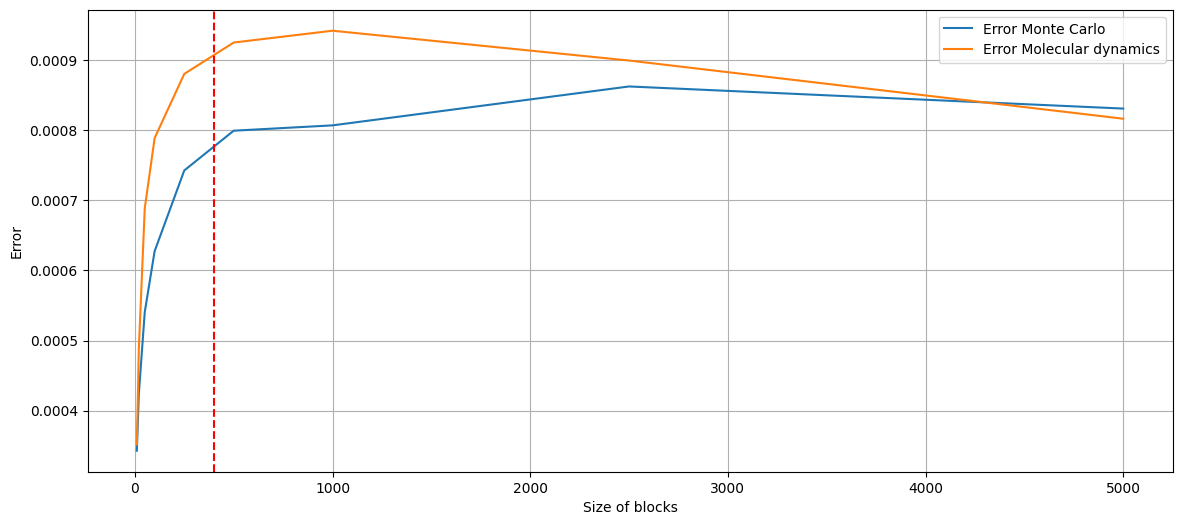

In [42]:
plt.figure(figsize=(14, 6))
plt.plot(L, err_1, label = "Error Monte Carlo")
plt.plot(L, err_2, label =  "Error Molecular dynamics")
plt.xlabel("Size of blocks")
plt.ylabel("Error")
plt.axvline(x =400, linestyle= '--', color = 'red')
plt.legend()


plt.grid(True)
plt.show()



Notiamo che all'inizio l'errore è sottostimato a causa dell'autocorrelazione per passi vicini, poi questo aumenterà molto velocemente fino a diventare costante una volta che abbiamo i blocchi abbastanza lunghi da essere scorrelati tra loro.
Prima avevamo dedotto dal grafico che dopo 400 passi i valori fossero scorrelati e qua ne abbiamo la conferma dall'errore del data blocking, infatti circa dopo 400 il valore si stabilizza.

## Exercise 7.4

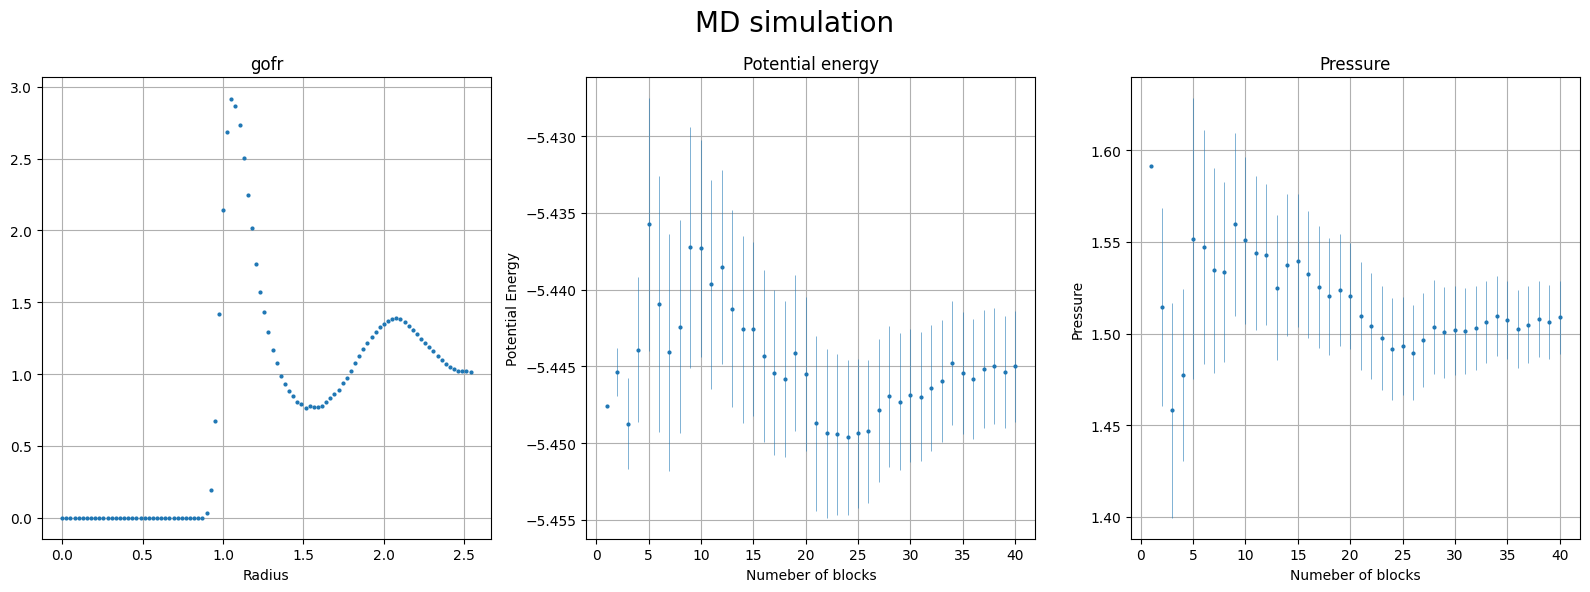

In [ ]:
position_md, frequency_md, err_gofr_md = np.loadtxt("../OUTPUT/MD_data/gofr.dat", unpack = True)
i, penergy, penergy_err = np.loadtxt("../OUTPUT/MD_data/potential_energy.dat", usecols= (0, 2, 3), unpack = True)
j, pressure, pressure_err = np.loadtxt("../OUTPUT/MD_data/pressure.dat",usecols= (0,2,3), unpack = True)

fig, (ax1, ax2, ax3)= plt.subplots(1, 3, figsize=(16, 6))

fig.suptitle("MD simulation", fontsize= 20)

ax1.errorbar(position_md, frequency_md/35, err_gofr_md, fmt='o', markersize=2, elinewidth=0.4 )
ax1.grid(True)
ax1.set_title("gofr")
ax1.set_xlabel("Radius")

ax2.errorbar(i, penergy, penergy_err, fmt ='o', markersize = 2 , elinewidth=0.4)
ax2.grid(True)
ax2.set_title("Potential energy")
ax2.set_xlabel("Numeber of blocks")
ax2.set_ylabel("Potential Energy")


ax3.errorbar(j, pressure, pressure_err, fmt ='o', markersize = 2 , elinewidth=0.4)
ax3.set_title("Pressure")
ax3.set_xlabel("Numeber of blocks")
ax3.set_ylabel("Pressure")
ax3.grid(True)

plt.tight_layout()
plt.show()

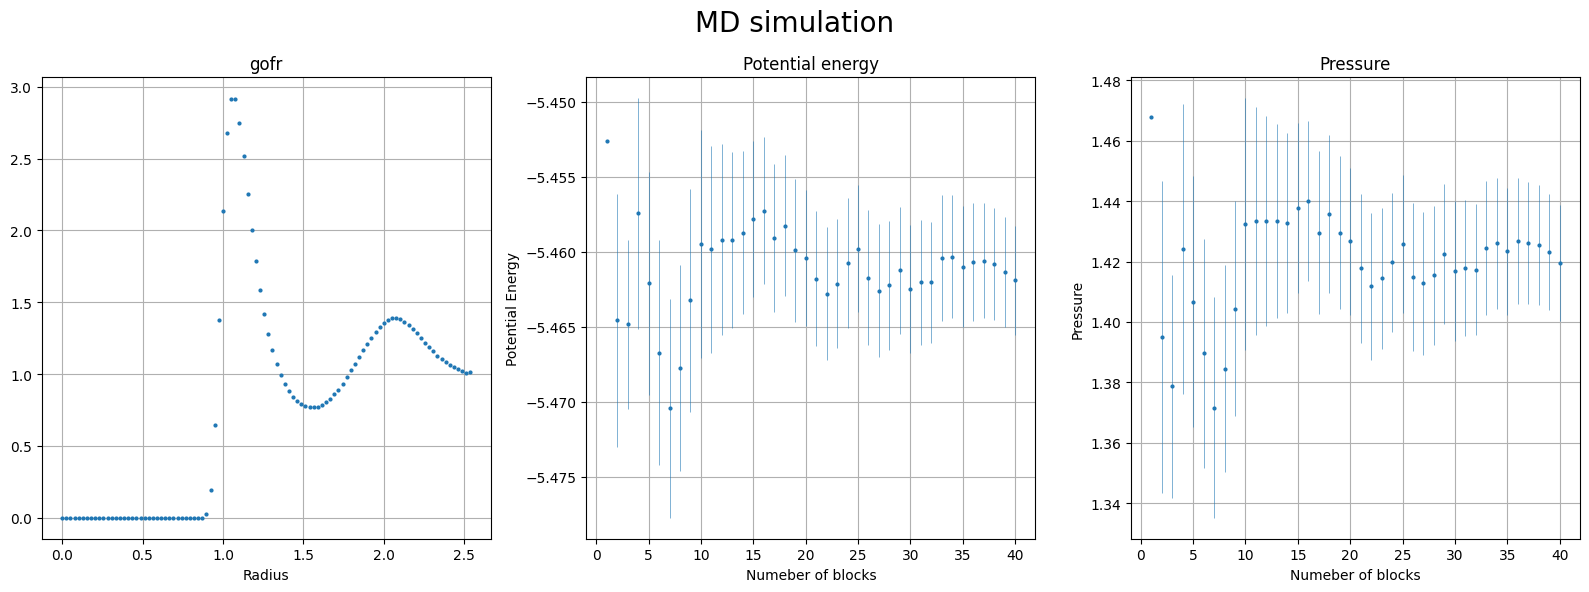

In [ ]:
position_md, frequency_md, err_gofr_md = np.loadtxt("../OUTPUT/MC_data/gofr.dat", unpack = True)
i, penergy, penergy_err = np.loadtxt("../OUTPUT/MC_data/potential_energy.dat", usecols= (0, 2, 3), unpack = True)
j, pressure, pressure_err = np.loadtxt("../OUTPUT/MC_data/pressure.dat",usecols= (0,2,3), unpack = True)

fig, (ax1, ax2, ax3)= plt.subplots(1, 3, figsize=(16, 6))

fig.suptitle("MC simulation", fontsize= 20)

ax1.errorbar(position_md, frequency_md/35, err_gofr_md, fmt='o', markersize=2, elinewidth=0.4 )
ax1.grid(True)
ax1.set_title("gofr")
ax1.set_xlabel("Radius")

ax2.errorbar(i, penergy, penergy_err, fmt ='o', markersize = 2 , elinewidth=0.4)
ax2.grid(True)
ax2.set_title("Potential energy")
ax2.set_xlabel("Numeber of blocks")
ax2.set_ylabel("Potential Energy")


ax3.errorbar(j, pressure, pressure_err, fmt ='o', markersize = 2 , elinewidth=0.4)
ax3.set_title("Pressure")
ax3.set_xlabel("Numeber of blocks")
ax3.set_ylabel("Pressure")
ax3.grid(True)

plt.tight_layout()
plt.show()

Vediamo che i due algoritmi in condizioni simili presentano risultati simili.